<a href="https://colab.research.google.com/github/Jayasuria12/Basic-Portfolio/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 NeuraThy — Thyroid Binding Protein Disease Prediction
## Stacking Ensemble Learning · UCI allbp Dataset

---

| | |
|---|---|
| **Project** | NeuraThy — Intelligent Thyroid Analysis |
| **Dataset** | UCI allbp (allbp.data) — 2,800 samples · 28 features · 3 classes |
| **Models** | Random Forest · AdaBoost · Bagging · Stacking Ensemble |
| **Meta-learner** | Logistic Regression |
| **Evaluation** | Test accuracy · 5-fold CV · Macro-AUC · Confusion Matrix |

---

### 📋 Notebook Sections
1. Install & Import Libraries  
2. Mount Google Drive & Load Dataset  
3. Data Exploration & Visualisation  
4. Preprocessing (Leakage-Free)  
5. Cross-Validation  
6. Model Training  
7. Evaluation — Accuracy, Confusion Matrix, ROC  
8. Feature Importance  
9. Single Patient Prediction  
10. Save Model  


## ✅ Step 1 — Install & Import Libraries

In [8]:
# Install any missing packages
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, pickle
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing    import OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.impute            import SimpleImputer
from sklearn.ensemble          import (
    RandomForestClassifier, AdaBoostClassifier,
    BaggingClassifier, StackingClassifier
)
from sklearn.tree              import DecisionTreeClassifier
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

print('✅ All libraries imported successfully')
print(f'   NumPy    : {np.__version__}')
print(f'   Pandas   : {pd.__version__}')
import sklearn; print(f'   Sklearn  : {sklearn.__version__}')

✅ All libraries imported successfully
   NumPy    : 2.0.2
   Pandas   : 2.2.2
   Sklearn  : 1.6.1


## 📂 Step 2 — Mount Google Drive & Load Dataset

In [9]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted')

Mounted at /content/drive
✅ Google Drive mounted


In [10]:
# ── UPDATE THIS PATH to your allbp.data location in Google Drive ──────────
DATA_PATH = '/content/drive/MyDrive/Dataset/thyroid_disease/allbp.data'
# ──────────────────────────────────────────────────────────────────────────

# Check file exists
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f'\n❌ File not found: {DATA_PATH}\n'
        f'   Please update DATA_PATH to match your Google Drive folder.\n'
        f'   Example: /content/drive/MyDrive/Dataset/thyroid_disease/allbp.data'
    )

# Column names
COLS = [
    'age','sex','on_thyroxine','query_on_thyroxine','on_antithyroid_medication',
    'sick','pregnant','thyroid_surgery','I131_treatment','query_hypothyroid',
    'query_hyperthyroid','lithium','goitre','tumor','hypopituitary','psych',
    'TSH_measured','TSH','T3_measured','T3','TT4_measured','TT4',
    'T4U_measured','T4U','FTI_measured','FTI','TBG_measured','TBG',
    'referral_source','target'
]

df_raw = pd.read_csv(DATA_PATH, header=None, names=COLS)

# Clean target: strip '|id' suffix
df_raw['target'] = df_raw['target'].str.split('|').str[0].str.strip()
df_raw.replace('?', np.nan, inplace=True)

print(f'✅ Dataset loaded successfully')
print(f'   Shape  : {df_raw.shape}')
print(f'   Columns: {df_raw.shape[1]}')
print(f'   Rows   : {df_raw.shape[0]:,}')
df_raw.head(3)

✅ Dataset loaded successfully
   Shape  : (2800, 30)
   Columns: 30
   Rows   : 2,800


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,NaN,SVHC,negative.
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,NaN,f,NaN,f,NaN,other,negative.
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,NaN,other,negative.


## 📊 Step 3 — Data Exploration & Visualisation

In [11]:
# ── Class Distribution ────────────────────────────────────────────────────
print('='*50)
print('CLASS DISTRIBUTION')
print('='*50)
class_counts = df_raw['target'].value_counts()
total = len(df_raw)
for cls, cnt in class_counts.items():
    bar = '█' * int(cnt / total * 40)
    print(f'  {cls:<30} {cnt:>5}  ({cnt/total*100:.1f}%)  {bar}')

print()
print('='*50)
print('MISSING VALUES')
print('='*50)
mv = df_raw.isnull().sum()
mv = mv[mv > 0].sort_values(ascending=False)
for col, n in mv.items():
    bar = '█' * int(n / total * 40)
    print(f'  {col:<30} {n:>5}  ({n/total*100:.1f}%)  {bar}')

CLASS DISTRIBUTION
  negative.                       2667  (95.2%)  ██████████████████████████████████████
  increased binding protein.       124  (4.4%)  █
  decreased binding protein.         9  (0.3%)  

MISSING VALUES
  TBG                             2800  (100.0%)  ████████████████████████████████████████
  T3                               585  (20.9%)  ████████
  T4U                              297  (10.6%)  ████
  FTI                              295  (10.5%)  ████
  TSH                              284  (10.1%)  ████
  TT4                              184  (6.6%)  ██
  sex                              110  (3.9%)  █
  age                                1  (0.0%)  


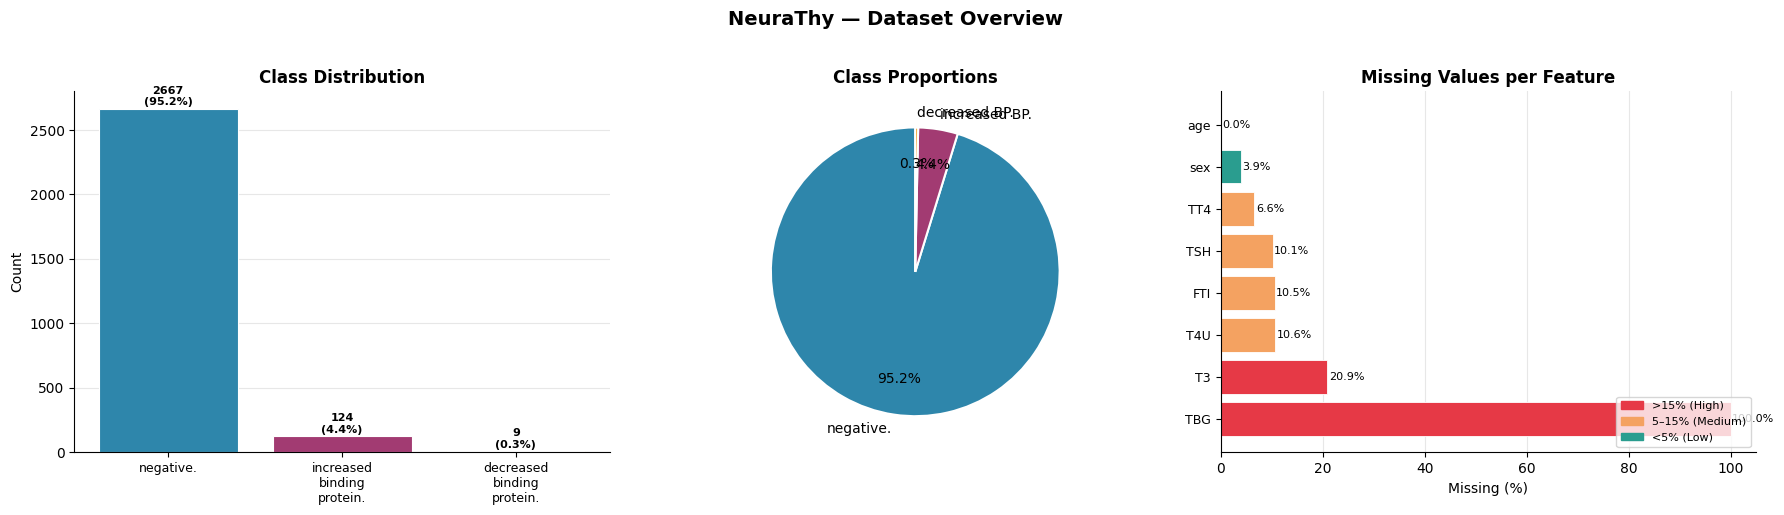

✅ Dataset overview plots saved


In [12]:
# ── Visualisation: 3 plots in one figure ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('NeuraThy — Dataset Overview', fontsize=14, fontweight='bold', y=1.02)

COLORS = ['#2E86AB', '#A23B72', '#F18F01']

# 1. Class distribution bar
ax = axes[0]
bars = ax.bar(range(len(class_counts)), class_counts.values,
              color=COLORS, edgecolor='white', linewidth=0.8)
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels([c.replace(' ', '\n') for c in class_counts.index],
                   fontsize=9)
ax.set_title('Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f'{val}\n({val/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# 2. Class distribution pie
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    class_counts.values,
    labels=[c.replace('binding protein','BP') for c in class_counts.index],
    colors=COLORS, autopct='%1.1f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax2.set_title('Class Proportions', fontweight='bold')

# 3. Missing values
ax3 = axes[2]
mv_plot = mv[mv > 0]
if len(mv_plot) > 0:
    pcts = (mv_plot / total * 100).values
    colors_mv = ['#E63946' if p > 15 else '#F4A261' if p > 5 else '#2A9D8F'
                 for p in pcts]
    bars3 = ax3.barh(range(len(mv_plot)), pcts, color=colors_mv,
                     edgecolor='white', linewidth=0.6)
    ax3.set_yticks(range(len(mv_plot)))
    ax3.set_yticklabels(mv_plot.index, fontsize=9)
    ax3.set_xlabel('Missing (%)')
    ax3.set_title('Missing Values per Feature', fontweight='bold')
    for bar, pct in zip(bars3, pcts):
        ax3.text(pct + 0.3, bar.get_y()+bar.get_height()/2,
                 f'{pct:.1f}%', va='center', fontsize=8)
    ax3.xaxis.grid(True, alpha=0.3); ax3.set_axisbelow(True)
    for sp in ['top','right']: ax3.spines[sp].set_visible(False)
    patch_r = mpatches.Patch(color='#E63946', label='>15% (High)')
    patch_y = mpatches.Patch(color='#F4A261', label='5–15% (Medium)')
    patch_g = mpatches.Patch(color='#2A9D8F', label='<5% (Low)')
    ax3.legend(handles=[patch_r,patch_y,patch_g], fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dataset overview plots saved')

Numeric Feature Statistics:
           age      TSH       T3      TT4      T4U      FTI
count  2799.00  2516.00  2215.00  2616.00  2503.00  2505.00
mean     51.84     4.67     2.02   109.07     1.00   110.79
std      20.46    21.45     0.82    35.39     0.19    32.88
min       1.00     0.00     0.05     2.00     0.31     2.00
25%      36.00     0.44     1.60    88.00     0.88    93.00
50%      54.00     1.40     2.00   104.00     0.98   107.00
75%      67.00     2.60     2.40   125.00     1.08   124.00
max     455.00   478.00    10.60   430.00     2.12   395.00


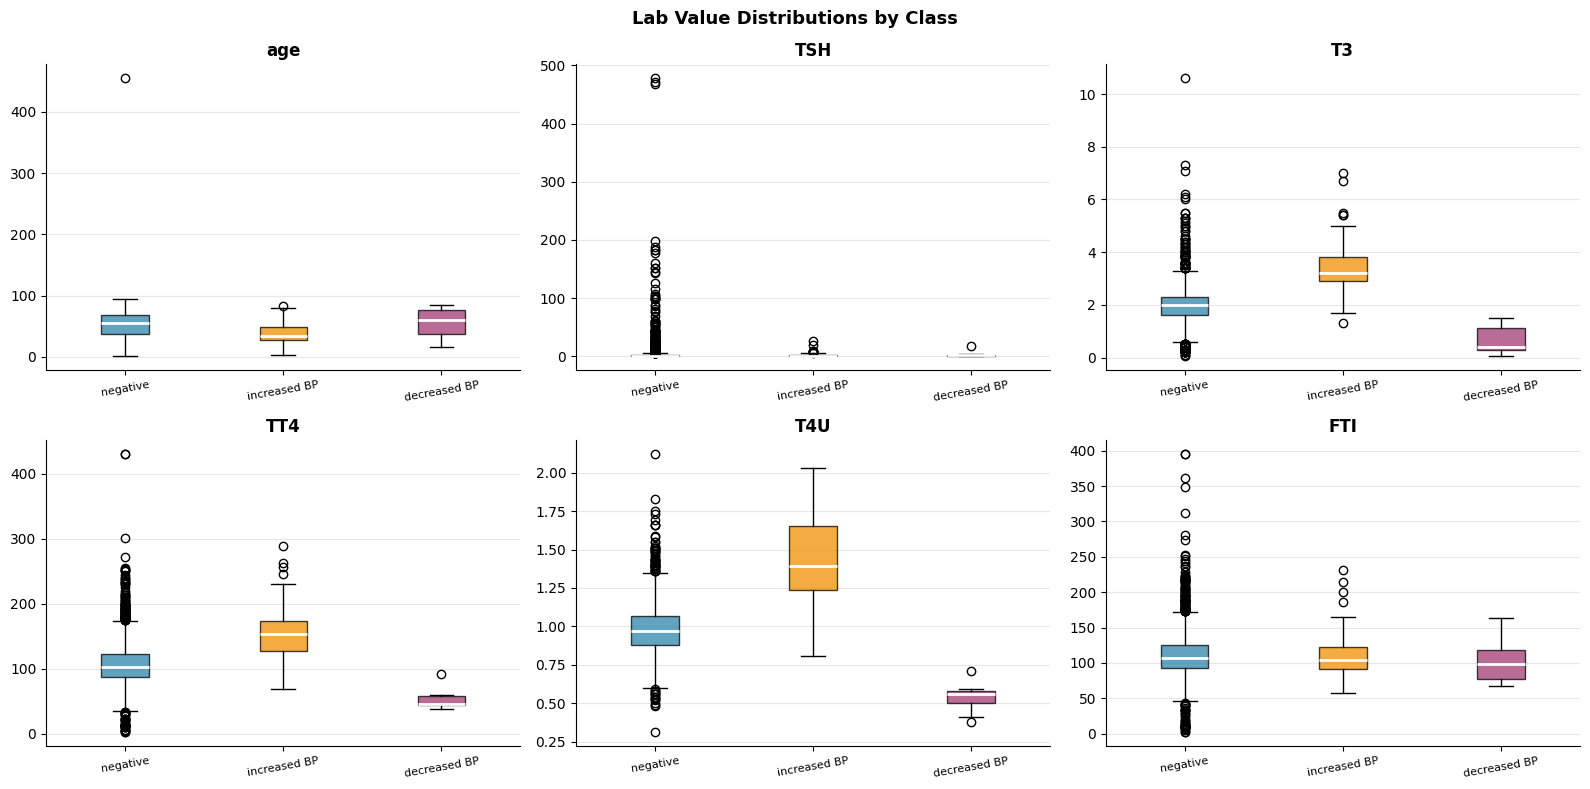

✅ Lab distribution plots saved


In [13]:
# ── Numeric feature statistics ─────────────────────────────────────────────
num_cols = ['age','TSH','T3','TT4','T4U','FTI']
df_num = df_raw[num_cols].apply(pd.to_numeric, errors='coerce')
print('Numeric Feature Statistics:')
print(df_num.describe().round(2).to_string())

# Box plots per class
df_plot = df_num.copy()
df_plot['target'] = df_raw['target']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Lab Value Distributions by Class', fontsize=13, fontweight='bold')
palette = {'negative.':'#2E86AB', 'increased binding protein.':'#F18F01',
           'decreased binding protein.':'#A23B72'}

for ax, col in zip(axes.flat, num_cols):
    data_col = df_plot.dropna(subset=[col])
    groups = [data_col[data_col['target']==c][col].values
              for c in df_raw['target'].unique() if c in data_col['target'].unique()]
    labels = [c.replace('binding protein','BP').replace('.','').strip()
              for c in df_raw['target'].unique()
              if c in data_col['target'].unique()]
    bp = ax.boxplot(groups, patch_artist=True, notch=False,
                    medianprops=dict(color='white',linewidth=2))
    for patch, color in zip(bp['boxes'], list(palette.values())):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(labels, fontsize=8, rotation=10)
    ax.set_title(col, fontweight='bold')
    ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('lab_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Lab distribution plots saved')

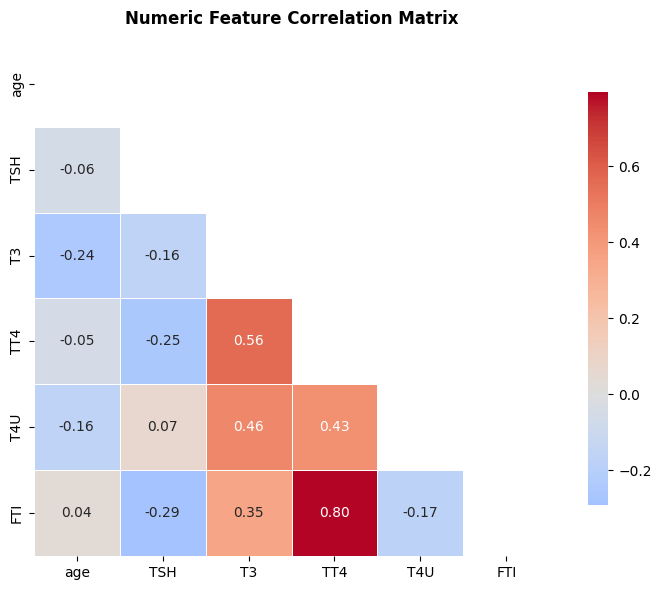

✅ Correlation heatmap saved


In [14]:
# ── Correlation heatmap (numeric features) ────────────────────────────────
df_corr = df_num.apply(pd.to_numeric, errors='coerce')
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, square=True, cbar_kws={'shrink':0.8})
ax.set_title('Numeric Feature Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Correlation heatmap saved')

## 🔧 Step 4 — Preprocessing (Leakage-Free)

In [15]:
print('='*55)
print('PREPROCESSING PIPELINE')
print('='*55)

# Work on a copy
df = df_raw.copy()

# Drop TBG — 100% missing
df.drop(columns=['TBG','TBG_measured'], inplace=True, errors='ignore')
print(f'  [1] Dropped TBG (100% missing)   → {df.shape[1]} features remain')

X = df.drop(columns=['target']).copy()
y = df['target'].copy()
feature_cols = list(X.columns)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f'  [2] Target encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Identify column types
cat_cols = [c for c in feature_cols if X[c].dtype == 'object']
num_cols = [c for c in feature_cols if X[c].dtype != 'object']
print(f'  [3] Categorical cols : {len(cat_cols)}')
print(f'      Numeric cols     : {len(num_cols)}')

# ── CRITICAL: Split BEFORE fitting any transformer ────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
print(f'  [4] Train/test split : X_train={X_train.shape}  X_test={X_test.shape}')
print(f'      stratify=y       → class balance preserved')

# OrdinalEncoder — fit on TRAIN only
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train = X_train.copy(); X_test = X_test.copy()
X_train[cat_cols] = oe.fit_transform(X_train[cat_cols].astype(str))
X_test[cat_cols]  = oe.transform(X_test[cat_cols].astype(str))
print(f'  [5] OrdinalEncoder   → fit on X_train only ✓')

# Convert all to numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test  = X_test.apply(pd.to_numeric, errors='coerce')

# SimpleImputer — fit on TRAIN only
imp = SimpleImputer(strategy='most_frequent')
X_train_imp = imp.fit_transform(X_train.values)
X_test_imp  = imp.transform(X_test.values)
print(f'  [6] SimpleImputer    → fit on X_train only ✓  (strategy=most_frequent)')

# StandardScaler — fit on TRAIN only
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_imp)
X_test_s  = scaler.transform(X_test_imp)
print(f'  [7] StandardScaler   → fit on X_train only ✓  (zero mean, unit var)')

print()
print(f'  Final shapes  →  X_train_s: {X_train_s.shape}   X_test_s: {X_test_s.shape}')
print('  ✅ Preprocessing complete — NO data leakage')

PREPROCESSING PIPELINE
  [1] Dropped TBG (100% missing)   → 28 features remain
  [2] Target encoded: {'decreased binding protein.': np.int64(0), 'increased binding protein.': np.int64(1), 'negative.': np.int64(2)}
  [3] Categorical cols : 27
      Numeric cols     : 0
  [4] Train/test split : X_train=(2240, 27)  X_test=(560, 27)
      stratify=y       → class balance preserved
  [5] OrdinalEncoder   → fit on X_train only ✓
  [6] SimpleImputer    → fit on X_train only ✓  (strategy=most_frequent)
  [7] StandardScaler   → fit on X_train only ✓  (zero mean, unit var)

  Final shapes  →  X_train_s: (2240, 27)   X_test_s: (560, 27)
  ✅ Preprocessing complete — NO data leakage


## 📈 Step 5 — Cross-Validation (5-Fold Stratified)

In [16]:
print('='*55)
print('5-FOLD STRATIFIED CROSS-VALIDATION')
print('='*55)
print('Running CV on X_train only (prevents leakage)...')
print()

# Define models
rf_cv  = RandomForestClassifier(n_estimators=300, max_depth=15,
                                  min_samples_split=5, random_state=42, n_jobs=-1)
adb_cv = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                              n_estimators=200, learning_rate=0.5, random_state=42)
bg_cv  = BaggingClassifier(n_estimators=200, max_samples=0.8,
                             max_features=0.8, random_state=42, n_jobs=-1)
st_cv  = StackingClassifier(
    estimators=[('rf', rf_cv), ('adb', adb_cv), ('bg', bg_cv)],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs'),
    cv=5
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in [('Random Forest', rf_cv),
                     ('AdaBoost',      adb_cv),
                     ('Bagging',       bg_cv),
                     ('Stacking',      st_cv)]:
    scores = cross_val_score(model, X_train_s, y_train,
                             cv=cv5, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    bar = '█' * int(scores.mean() * 50 - 46)
    print(f'  {name:<15}  Mean: {scores.mean()*100:.2f}%  ' # Corrected f-string
          f'Std: ±{scores.std()*100:.2f}%  [{bar}]')

print()
print('✅ Cross-validation complete')

5-FOLD STRATIFIED CROSS-VALIDATION
Running CV on X_train only (prevents leakage)...

  Random Forest    Mean: 96.92%  Std: ±0.79%  [██]
  AdaBoost         Mean: 96.52%  Std: ±0.98%  [██]
  Bagging          Mean: 96.74%  Std: ±0.89%  [██]
  Stacking         Mean: 96.79%  Std: ±0.81%  [██]

✅ Cross-validation complete


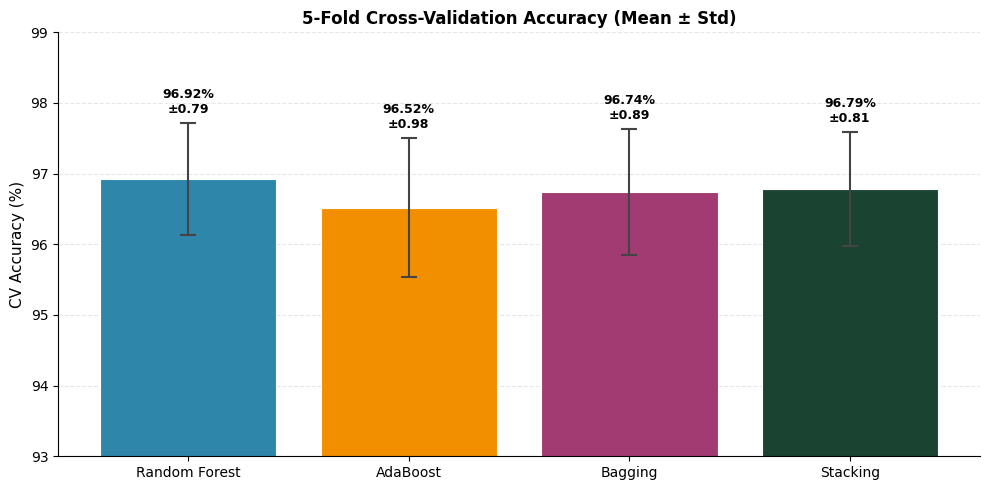

✅ CV results plot saved


In [17]:
# ── CV results plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

model_names = list(cv_results.keys())
means = [cv_results[m].mean()*100 for m in model_names]
stds  = [cv_results[m].std()*100  for m in model_names]

colors = ['#2E86AB','#F18F01','#A23B72','#1B4332']
bars = ax.bar(model_names, means, yerr=stds, capsize=6,
              color=colors, edgecolor='white', linewidth=0.8,
              error_kw=dict(ecolor='#444', lw=1.5, capthick=1.5))
ax.set_ylim(93, 99)
ax.set_ylabel('CV Accuracy (%)', fontsize=11)
ax.set_title('5-Fold Cross-Validation Accuracy (Mean ± Std)', fontweight='bold', fontsize=12)
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+std+0.1,
            f'{mean:.2f}%\n±{std:.2f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')
ax.yaxis.grid(True, alpha=0.3, linestyle='--'); ax.set_axisbelow(True)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ CV results plot saved')

## 🤖 Step 6 — Model Training

In [18]:
print('='*55)
print('TRAINING ALL MODELS ON FULL X_train')
print('='*55)

# ── Define final models ────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=5,
    random_state=42, n_jobs=-1
)
adb_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=200, learning_rate=0.5, random_state=42
)
bg_model = BaggingClassifier(
    n_estimators=200, max_samples=0.8, max_features=0.8,
    random_state=42, n_jobs=-1
)
stack_model = StackingClassifier(
    estimators=[
        ('rf',  rf_model),
        ('adb', adb_model),
        ('bg',  bg_model)
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs'),
    cv=5,
    passthrough=False
)

# ── Train all ──────────────────────────────────────────────────────────────
print('  Training Random Forest ...')
rf_model.fit(X_train_s, y_train)
print('  ✅ Random Forest trained')

print('  Training AdaBoost ...')
adb_model.fit(X_train_s, y_train)
print('  ✅ AdaBoost trained')

print('  Training Bagging ...')
bg_model.fit(X_train_s, y_train)
print('  ✅ Bagging trained')

print('  Training Stacking Ensemble (this may take a moment)...')
stack_model.fit(X_train_s, y_train)
print('  ✅ Stacking Ensemble trained')

print()
print('✅ All 4 models trained successfully!')

TRAINING ALL MODELS ON FULL X_train
  Training Random Forest ...
  ✅ Random Forest trained
  Training AdaBoost ...
  ✅ AdaBoost trained
  Training Bagging ...
  ✅ Bagging trained
  Training Stacking Ensemble (this may take a moment)...
  ✅ Stacking Ensemble trained

✅ All 4 models trained successfully!


## 📊 Step 7 — Evaluation: Accuracy, Confusion Matrix, ROC Curve

In [19]:
# ── Test set predictions ───────────────────────────────────────────────────
preds = {
    'Random Forest' : rf_model.predict(X_test_s),
    'AdaBoost'      : adb_model.predict(X_test_s),
    'Bagging'       : bg_model.predict(X_test_s),
    'Stacking'      : stack_model.predict(X_test_s),
}
accs = {m: round(accuracy_score(y_test, p)*100, 2) for m, p in preds.items()}

print('='*55)
print('TEST SET ACCURACY (n=560 samples)')
print('='*55)
best = max(accs, key=accs.get)
for m, acc in accs.items():
    star = ' ← BEST' if m == best else ''
    bar  = '█' * int((acc - 90) * 4)
    print(f'  {m:<15}  {acc:.2f}%  {bar}{star}')

print()
print(f'  🏆 Best model   : {best} ({accs[best]:.2f}%)')

TEST SET ACCURACY (n=560 samples)
  Random Forest    97.14%  ████████████████████████████
  AdaBoost         98.21%  ████████████████████████████████
  Bagging          98.21%  ████████████████████████████████
  Stacking         98.39%  █████████████████████████████████ ← BEST

  🏆 Best model   : Stacking (98.39%)


In [20]:
# ── Classification report (Stacking) ──────────────────────────────────────
print('='*55)
print('CLASSIFICATION REPORT — Stacking Ensemble')
print('='*55)
print(classification_report(
    y_test, preds['Stacking'],
    target_names=le.classes_
))

CLASSIFICATION REPORT — Stacking Ensemble
                            precision    recall  f1-score   support

decreased binding protein.       0.00      0.00      0.00         2
increased binding protein.       1.00      0.72      0.84        25
                 negative.       0.98      1.00      0.99       533

                  accuracy                           0.98       560
                 macro avg       0.66      0.57      0.61       560
              weighted avg       0.98      0.98      0.98       560



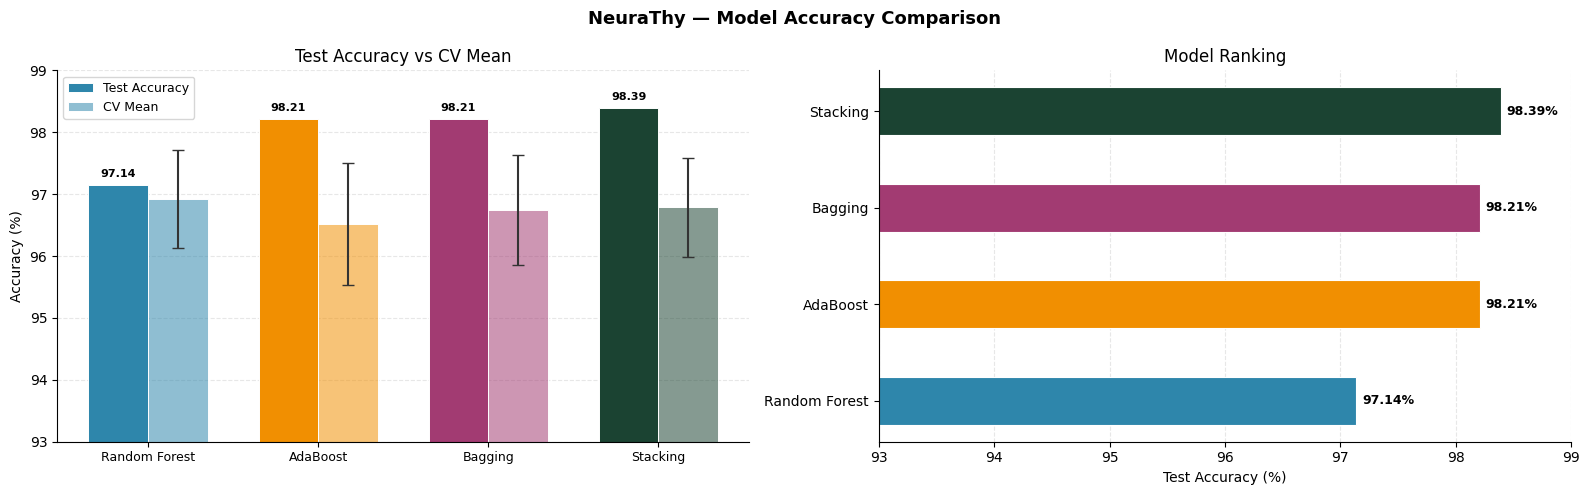

✅ Accuracy comparison plot saved


In [21]:
# ── Accuracy bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('NeuraThy — Model Accuracy Comparison', fontsize=13, fontweight='bold')

model_names = list(accs.keys())
acc_vals    = list(accs.values())
cv_means    = [cv_results[m].mean()*100 for m in model_names]
cv_stds     = [cv_results[m].std()*100  for m in model_names]
colors      = ['#2E86AB','#F18F01','#A23B72','#1B4332']
x = np.arange(len(model_names))
w = 0.35

# Grouped bar
ax = axes[0]
b1 = ax.bar(x - w/2, acc_vals, w, label='Test Accuracy',
            color=colors, edgecolor='white', linewidth=0.7)
b2 = ax.bar(x + w/2, cv_means, w, label='CV Mean',
            color=[c+'88' for c in colors],  # slightly transparent
            edgecolor='white', linewidth=0.7)
ax.errorbar(x + w/2, cv_means, yerr=cv_stds, fmt='none',
            ecolor='#333', lw=1.5, capsize=4)
ax.set_ylim(93, 99)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Test Accuracy vs CV Mean')
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.3, linestyle='--'); ax.set_axisbelow(True)
for b, v in zip(b1, acc_vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
            f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# Horizontal comparison
ax2 = axes[1]
ax2.barh(model_names, acc_vals, color=colors, edgecolor='white',
          linewidth=0.8, height=0.5)
ax2.set_xlim(93, 99)
ax2.set_xlabel('Test Accuracy (%)')
ax2.set_title('Model Ranking')
for i, v in enumerate(acc_vals):
    ax2.text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=9, fontweight='bold')
ax2.xaxis.grid(True, alpha=0.3, linestyle='--'); ax2.set_axisbelow(True)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Accuracy comparison plot saved')

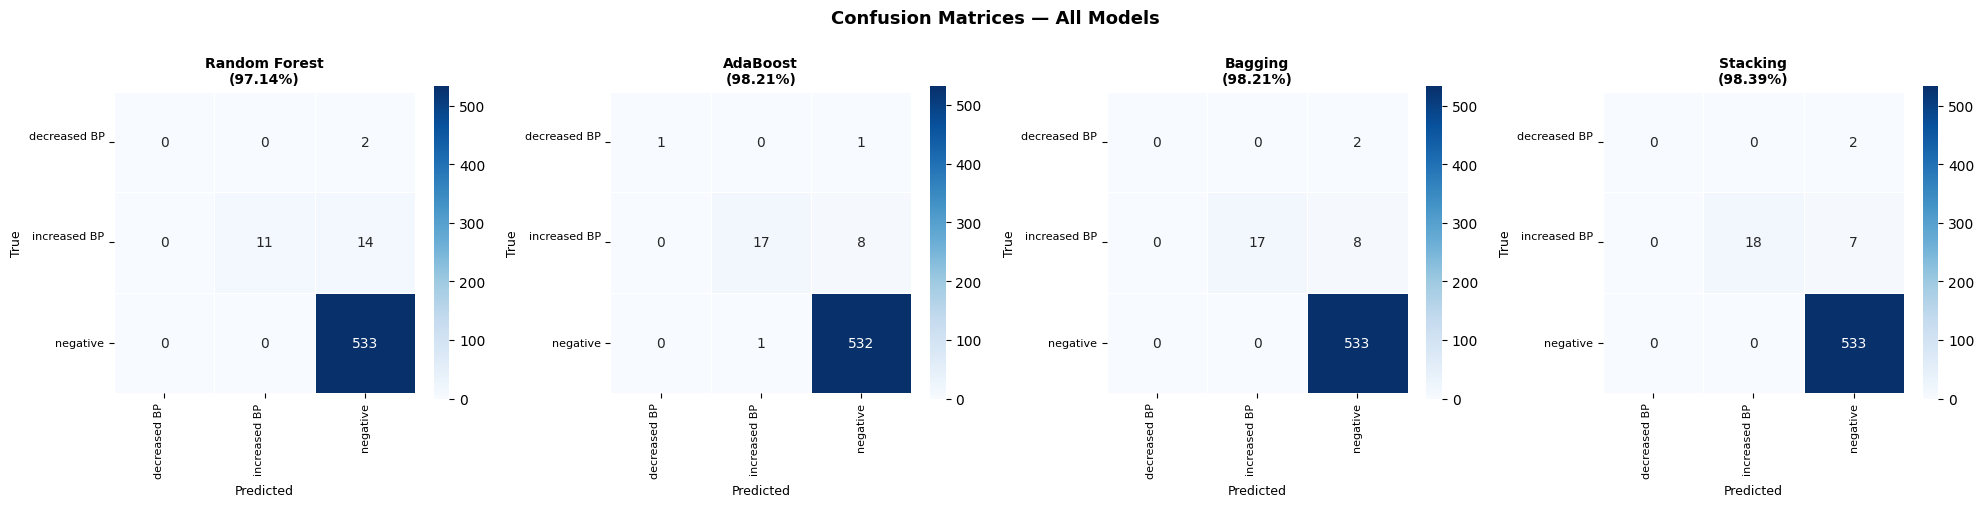

✅ Confusion matrices saved


In [22]:
# ── Confusion Matrices (all 4 models) ─────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')

class_labels = [c.replace('binding protein.','BP\n').replace('.','')
                for c in le.classes_]

model_objects = {
    'Random Forest' : rf_model,
    'AdaBoost'      : adb_model,
    'Bagging'       : bg_model,
    'Stacking'      : stack_model,
}

for ax, (name, model) in zip(axes, model_objects.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_s))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=0.5, square=True,
                cbar_kws={'shrink': 0.8})
    acc = accuracy_score(y_test, model.predict(X_test_s)) * 100
    ax.set_title(f'{name}\n({acc:.2f}%)', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved')

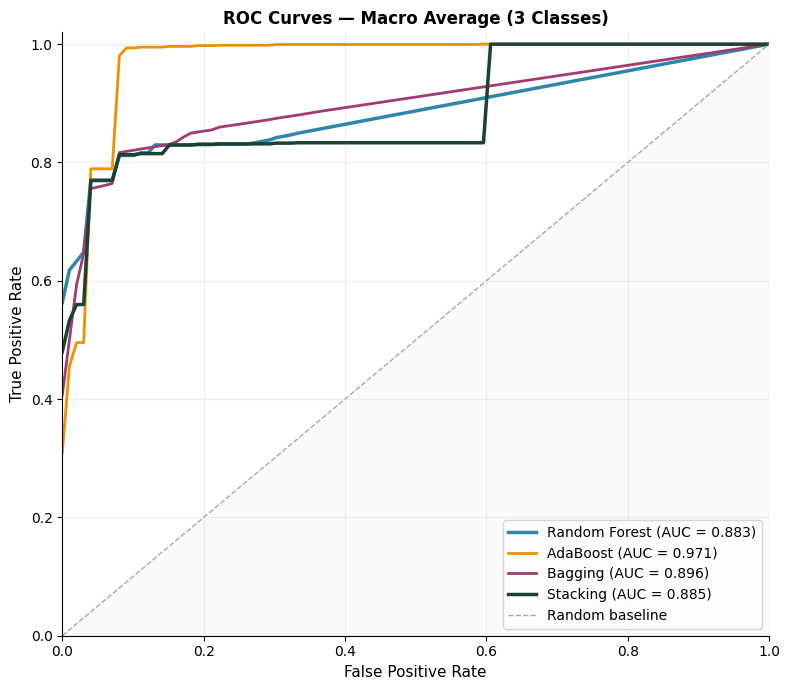


AUC Scores (macro average):
  AdaBoost         AUC = 0.9712
  Bagging          AUC = 0.8962
  Stacking         AUC = 0.8852
  Random Forest    AUC = 0.8833
✅ ROC curves saved


In [23]:
# ── ROC Curves (macro average) ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

roc_colors = {'Random Forest':'#2E86AB','AdaBoost':'#F18F01',
              'Bagging':'#A23B72','Stacking':'#1B4332'}
roc_lw     = {'Random Forest':2.5,'AdaBoost':2.0,'Bagging':2.0,'Stacking':2.5}

auc_scores = {}
for name, model in model_objects.items():
    proba   = model.predict_proba(X_test_s)
    all_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros(100)
    class_aucs = []
    for i in range(len(le.classes_)):
        y_bin = (y_test == i).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, proba[:, i])
        mean_tpr += np.interp(all_fpr, fpr, tpr)
        class_aucs.append(auc(fpr, tpr))
    mean_tpr /= len(le.classes_)
    macro_auc = auc(all_fpr, mean_tpr)
    auc_scores[name] = macro_auc
    ax.plot(all_fpr, mean_tpr, color=roc_colors[name],
            lw=roc_lw[name], label=f'{name} (AUC = {macro_auc:.3f})')

ax.plot([0,1],[0,1],'--',color='#AAAAAA',lw=1,label='Random baseline')
ax.fill_between([0,1],[0,1],alpha=0.05,color='#AAAAAA')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Macro Average (3 Classes)', fontweight='bold', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.yaxis.grid(True,alpha=0.2); ax.xaxis.grid(True,alpha=0.2)
ax.set_axisbelow(True)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAUC Scores (macro average):')
for name, score in sorted(auc_scores.items(), key=lambda x: -x[1]):
    print(f'  {name:<15}  AUC = {score:.4f}')
print('✅ ROC curves saved')

## 🔍 Step 8 — Feature Importance Analysis

FEATURE IMPORTANCE — Random Forest (Top 15)
   1. T4U                              0.2550  █████████████████████████
   2. T3                               0.1630  ████████████████
   3. TT4                              0.1119  ███████████
   4. FTI                              0.0815  ████████
   5. age                              0.0774  ███████
   6. pregnant                         0.0630  ██████
   7. TSH                              0.0617  ██████
   8. referral_source                  0.0527  █████
   9. T3_measured                      0.0254  ██
  10. sex                              0.0170  █
  11. FTI_measured                     0.0164  █
  12. T4U_measured                     0.0151  █
  13. tumor                            0.0135  █
  14. on_thyroxine                     0.0130  █
  15. query_hyperthyroid               0.0063  


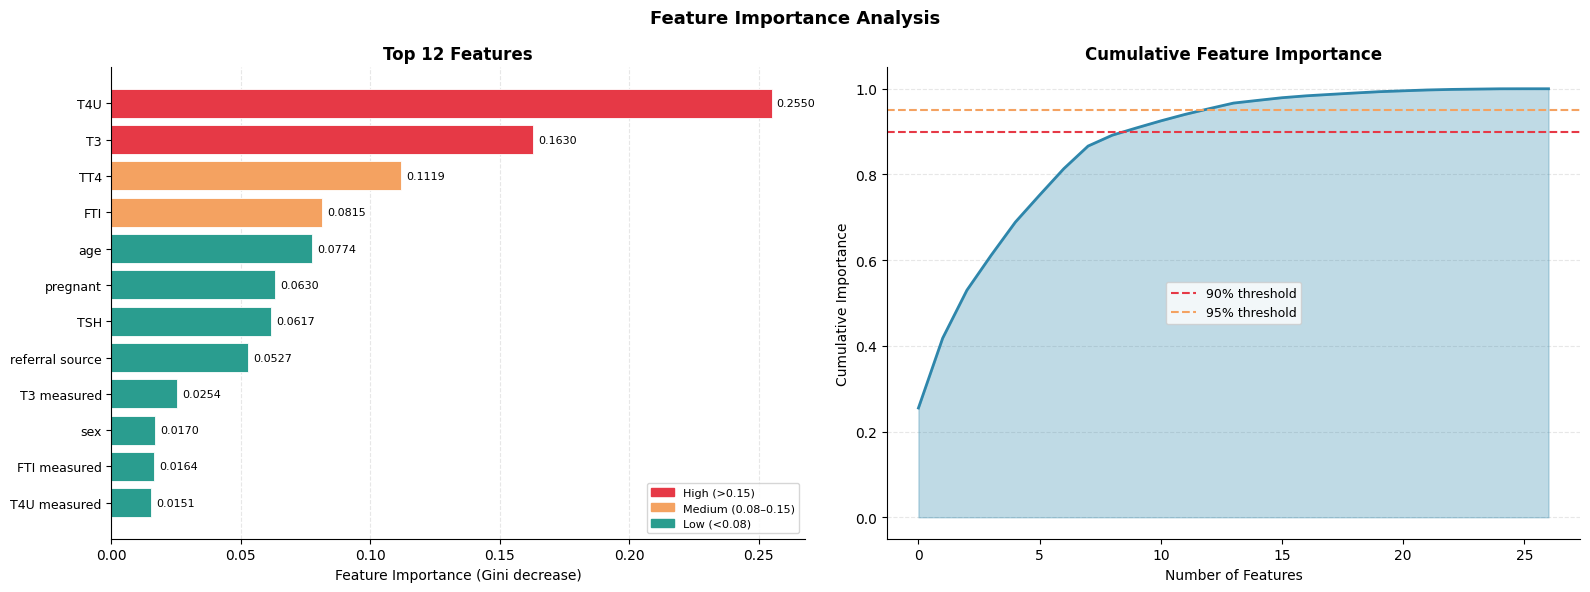

✅ Feature importance plots saved


In [28]:
fi = pd.Series(rf_model.feature_importances_, index=feature_cols)
fi_sorted = fi.sort_values(ascending=False)

print('='*55)
print('FEATURE IMPORTANCE \u2014 Random Forest (Top 15)')
print('='*55)
for rank, (feat, importance) in enumerate(fi_sorted.head(15).items(), 1):
    bar = '█' * int(importance * 100)
    print(f'  {rank:>2}. {feat:<32} {importance:.4f}  {bar}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance Analysis', fontsize=13, fontweight='bold')

# Top 12 bar chart
ax = axes[0]
top12 = fi_sorted.head(12)
color_imp = ['#E63946' if v > 0.15 else '#F4A261' if v > 0.08
             else '#2A9D8F' for v in top12.values]
bars = ax.barh(range(len(top12)), top12.values,
               color=color_imp, edgecolor='white', linewidth=0.6)
ax.set_yticks(range(len(top12)))
ax.set_yticklabels([f.replace('_',' ') for f in top12.index], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gini decrease)')
ax.set_title('Top 12 Features', fontweight='bold')
for bar, v in zip(bars, top12.values):
    ax.text(v+0.002, bar.get_y()+bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8)
ax.xaxis.grid(True,alpha=0.3,linestyle='--'); ax.set_axisbelow(True)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

patch_r = mpatches.Patch(color='#E63946', label='High (>0.15)')
patch_y = mpatches.Patch(color='#F4A261', label='Medium (0.08\u20130.15)')
patch_g = mpatches.Patch(color='#2A9D8F', label='Low (<0.08)')
ax.legend(handles=[patch_r,patch_y,patch_g], fontsize=8, loc='lower right')

# Cumulative importance
ax2 = axes[1]
cumul = fi_sorted.cumsum()
ax2.fill_between(range(len(cumul)), cumul.values, alpha=0.3, color='#2E86AB')
ax2.plot(range(len(cumul)), cumul.values, color='#2E86AB', linewidth=2)
ax2.axhline(0.90, color='#E63946', linestyle='--', lw=1.5, label='90% threshold')
ax2.axhline(0.95, color='#F4A261', linestyle='--', lw=1.5, label='95% threshold')

# Fix: Correctly get the number of features for 90% cumulative importance
if any(cumul >= 0.90):
    feature_name_at_90_percent = (cumul >= 0.90).idxmax()
    n90 = fi_sorted.index.get_loc(feature_name_at_90_percent) + 1 # 1-based count of features
else:
    n90 = len(cumul)
# The variable n90_idx was not used later in the cell, so it has been removed.

ax2.set_xlabel('Number of Features')
ax2.set_ylabel('Cumulative Importance')
ax2.set_title('Cumulative Feature Importance', fontweight='bold')
ax2.legend(fontsize=9)
ax2.yaxis.grid(True,alpha=0.3,linestyle='--'); ax2.set_axisbelow(True)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance plots saved')

## 🏁 Step 9 — Summary Table & Final Results

In [25]:
# ── Complete results summary ───────────────────────────────────────────────
summary_data = {
    'Model'         : list(accs.keys()),
    'Test Acc (%)'  : list(accs.values()),
    'CV Mean (%)'   : [round(cv_results[m].mean()*100,2) for m in accs],
    'CV Std (%)'    : [round(cv_results[m].std()*100,2)  for m in accs],
    'Macro AUC'     : [round(auc_scores[m],4) for m in accs],
}
summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Test Acc (%)', ascending=False).reset_index(drop=True)

print('='*70)
print('FINAL RESULTS SUMMARY')
print('='*70)
print(summary_df.to_string(index=False))
print('='*70)

best_acc_model = summary_df.iloc[0]['Model']
best_acc_val   = summary_df.iloc[0]['Test Acc (%)']
best_auc_idx   = summary_df['Macro AUC'].idxmax()
best_auc_model = summary_df.loc[best_auc_idx,'Model']
best_auc_val   = summary_df.loc[best_auc_idx,'Macro AUC']

print(f'\n  🏆 Best Test Accuracy : {best_acc_model} ({best_acc_val:.2f}%)')
print(f'  🏆 Best Macro AUC     : {best_auc_model} (AUC={best_auc_val:.4f})')
print(f'  📊 Total samples      : {len(df):,}')
print(f'  🎯 Test samples       : {len(y_test):,}')
print(f'  📁 Features used      : {len(feature_cols)}')

FINAL RESULTS SUMMARY
        Model  Test Acc (%)  CV Mean (%)  CV Std (%)  Macro AUC
     Stacking         98.39        96.79        0.81     0.8852
     AdaBoost         98.21        96.52        0.98     0.9712
      Bagging         98.21        96.74        0.89     0.8962
Random Forest         97.14        96.92        0.79     0.8833

  🏆 Best Test Accuracy : Stacking (98.39%)
  🏆 Best Macro AUC     : AdaBoost (AUC=0.9712)
  📊 Total samples      : 2,800
  🎯 Test samples       : 560
  📁 Features used      : 27


## 🔬 Step 10 — Single Patient Prediction

In [30]:
# ── Predict for a single patient ──────────────────────────────────────────
# Edit these values for a real patient
patient = {
    'age'                     : 45,
    'sex'                     : 'F',
    'on_thyroxine'            : 'f',
    'query_on_thyroxine'      : 'f',
    'on_antithyroid_medication': 't',   # ← key signal
    'sick'                    : 'f',
    'pregnant'                : 'f',
    'thyroid_surgery'         : 'f',
    'I131_treatment'          : 'f',
    'query_hypothyroid'       : 'f',
    'query_hyperthyroid'      : 'f',
    'lithium'                 : 'f',
    'goitre'                  : 'f',
    'tumor'                   : 'f',
    'hypopituitary'           : 'f',
    'psych'                   : 'f',
    'TSH_measured'            : 't',
    'TSH'                     : 1.3,
    'T3_measured'             : 't',
    'T3'                      : 2.1,
    'TT4_measured'            : 't',
    'TT4'                     : 110,
    'T4U_measured'            : 't',
    'T4U'                     : 0.95,
    'FTI_measured'            : 't',
    'FTI'                     : 105,
    'referral_source'         : 'other',
}

# Build DataFrame row matching training columns
patient_df = pd.DataFrame([{col: patient.get(col, np.nan) for col in feature_cols}])

# Apply same preprocessing
patient_df[cat_cols] = oe.transform(patient_df[cat_cols].astype(str))
patient_df = patient_df.apply(pd.to_numeric, errors='coerce')
patient_arr  = imp.transform(patient_df.values)
patient_s    = scaler.transform(patient_arr)

# Predict with all models
print('='*60)
print('SINGLE PATIENT PREDICTION')
print('='*60)
print(f'  Age     : {patient["age"]}  Sex: {patient["sex"]}')
print(f'  TSH     : {patient["TSH"]} mIU/L   T3: {patient["T3"]} nmol/L')
print(f'  TT4     : {patient["TT4"]} nmol/L  T4U: {patient["T4U"]}  FTI: {patient["FTI"]}')
print(f'  Antithyroid Med: {patient["on_antithyroid_medication"]}')
print()

for name, model in model_objects.items():
    proba = model.predict_proba(patient_s)[0]
    pred_idx = np.argmax(proba)
    pred_cls = le.classes_[pred_idx]
    conf     = proba[pred_idx] * 100
    print(f'  [{name:<15}]  → {pred_cls:<35} ({conf:.1f}%)')
    for cls, p in zip(le.classes_, proba):
        bar = '▓' * int(p * 20)
        print(f'     {cls:<35} {p*100:5.1f}%  {bar}')
    print()

AttributeError: 'float' object has no attribute 'transform'

In [ ]:
get_ipython().run_cell('#dt3Xnff7UAdX')

## 💾 Step 11 — Save Model to Google Drive

In [ ]:
# ── Save trained model and preprocessors ──────────────────────────────────
SAVE_DIR = '/content/drive/MyDrive/NeuraThy_Model'
os.makedirs(SAVE_DIR, exist_ok=True)

model_bundle = {
    'le'          : le,
    'oe'          : oe,
    'imp'         : imp,
    'scaler'      : scaler,
    'rf_model'    : rf_model,
    'adb_model'   : adb_model,
    'bg_model'    : bg_model,
    'stack_model' : stack_model,
    'feature_cols': feature_cols,
    'cat_cols'    : cat_cols,
    'classes'     : le.classes_.tolist(),
    'stats'       : {
        'test_accs' : accs,
        'auc_scores': auc_scores,
        'cv_results': {m: {'mean':cv_results[m].mean()*100,
                           'std': cv_results[m].std()*100}
                       for m in cv_results},
    }
}

save_path = os.path.join(SAVE_DIR, 'neura_thy_model.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(model_bundle, f)

size_mb = os.path.getsize(save_path) / 1024 / 1024
print(f'✅ Model saved to Google Drive')
print(f'   Path   : {save_path}')
print(f'   Size   : {size_mb:.2f} MB')
print()
print('   Contents:')
for k in model_bundle:
    print(f'     • {k}')

In [1]:
# ── Save all plots to Drive ────────────────────────────────────────────────
import os
import shutil
plots_dir = os.path.join(SAVE_DIR, 'plots')
os.makedirs(plots_dir, exist_ok=True)

plot_files = [
    'dataset_overview.png',
    'lab_distributions.png',
    'correlation_matrix.png',
    'cv_results.png',
    'accuracy_comparison.png',
    'confusion_matrices.png',
    'roc_curves.png',
    'feature_importance.png',
]

print('Saving plots to Google Drive...')
for f in plot_files:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(plots_dir, f))
        print(f'  ✅ {f}')
    else:
        print(f'  ⚠  {f} not found (re-run cell to generate)')

print()
print('='*55)
print('🎉 NeuraThy Colab Notebook Complete!')
print('='*55)
print(f'  Best accuracy : {best_acc_val:.2f}% ({best_acc_model})')
print(f'  Best AUC      : {best_auc_val:.4f} ({best_auc_model})')
print(f'  Model saved   : {save_path}')
print(f'  Plots saved   : {plots_dir}')
print()
print('  Copy neura_thy_model.pkl to NeuraThy/model/')
print('  then run: python backend/app.py')

NameError: name 'SAVE_DIR' is not defined